# So sánh dữ liệu gốc và dữ liệu sau khi nội suy về 100 điểm
Mục tiêu: Đảm bảo hình dáng (shape/trend) của tín hiệu không bị biến dạng khi ép về 100 timesteps.

Đang tải Plant_oil...
Đang tải Brewed_vinegar...
Đang tải Wine_spoilage...
Đang tải Chinese_wine...
Đang tải Coffee...


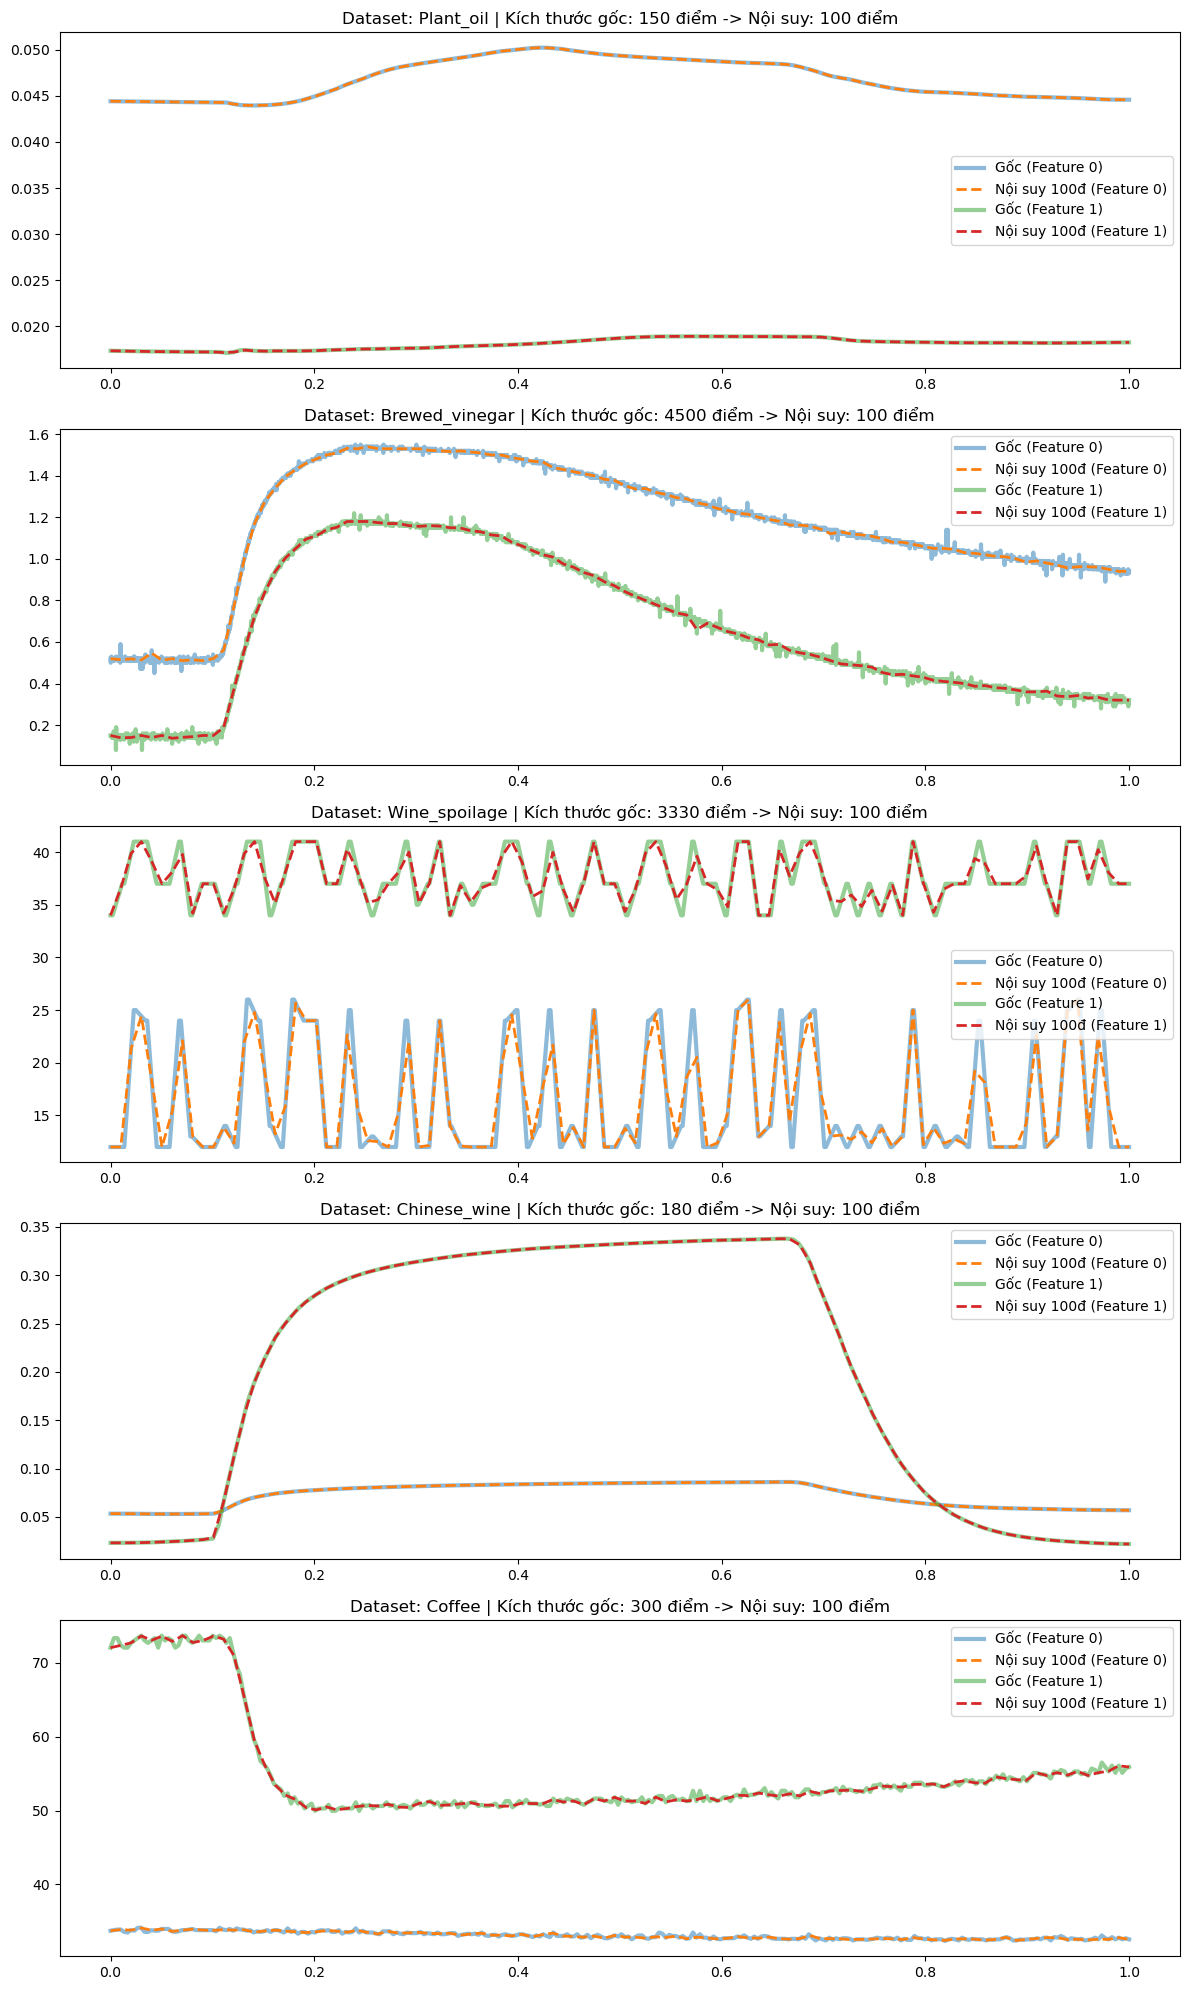

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataset import load_dataset, get_feature_columns
from config import DATASETS

target_timesteps = 100

fig, axes = plt.subplots(len(DATASETS), 1, figsize=(12, 4 * len(DATASETS)))
if len(DATASETS) == 1:
    axes = [axes]

for idx, (d_name, d_file) in enumerate(DATASETS.items()):
    print
    try:
        df = load_dataset(d_name)
    except Exception as e:
        print
        continue
        
    feature_cols = get_feature_columns(df)
    
    # Lấy measurement đầu tiên
    first_measurement_id = df['Measurement_Number'].iloc[0]
    group = df[df['Measurement_Number'] == first_measurement_id].sort_values('Time')
    
    features_orig = group[feature_cols].values
    orig_length = features_orig.shape[0]
    
    # Nội suy về 100 điểm
    features_new = np.zeros((target_timesteps, features_orig.shape[1]))
    for j in range(features_orig.shape[1]):
        features_new[:, j] = np.interp(
            np.linspace(0, 1, target_timesteps),
            np.linspace(0, 1, orig_length),
            features_orig[:, j]
        )
        
    ax = axes[idx]
    
    # Chỉ vẽ 2 features đầu tiên để tránh biểu đồ quá rối
    features_to_plot = min(2, features_orig.shape[1])
    for j in range(features_to_plot):
        ax.plot(np.linspace(0, 1, orig_length), features_orig[:, j], label=f'Gốc (Feature {j})', alpha=0.5, linewidth=3)
        ax.plot(np.linspace(0, 1, target_timesteps), features_new[:, j], '--', label=f'Nội suy 100đ (Feature {j})', linewidth=2)
        
    ax.set_title
    ax.legend()

plt.tight_layout()
plt.show()